# Try to create a gaussian pulse in rabi




In [2]:
import numpy as np
import matplotlib.pyplot as plt

# lets me import from a different directory
import sys 
sys.path.append("/Users/archie/documents/year4/project/code")

import spin_tools.hamiltonians as hamiltonians
from spin_tools.gates import *
import spin_tools.quantum_tools as qt
from spin_tools.floquet_tools import ccd_floquet

In [3]:
steel_blue, plum = "#4682B4", "#B44682"

## Create Gaussian Pulse Func

In [4]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10
rabi_freq = 0.005



tol = 10**-5
evaluation_points = 2000
evaluation_time = 1/(4*rabi_freq)

In [5]:
def gaussian_root_x_rabi(t, detuning):

    natural_freq = 10-detuning  # 10ghz   
    driving_freq = 10
    rabi_freq0 = 0.005
    
    pulse_length = 1 / (4*rabi_freq0)

    centre = pulse_length / 2
    width = pulse_length / 4

    area_tophat  = rabi_freq0 * pulse_length

    area_gauss = np.sqrt(2 * np.pi) * width

    # 4) Choose height so window×height has same area as top‐hat
    height = area_tophat / area_gauss

    rabi_freq = height * np.exp(-((t - centre)**2) / (2 * width**2))




    if t > pulse_length or t < 0:
        rabi_freq = 0


    
    return {
        'natural_freq': natural_freq,
        'driving_freq': driving_freq,
        'rabi_freq': rabi_freq,
    }

In [6]:
def top_hat_root_x_rabi(t, detuning):

    natural_freq = 10-detuning  # 10ghz   
    driving_freq = 10
    rabi_freq = 0.005

    #check t if pulse is on or off
    pulse_length = 1 / (4*rabi_freq)

    if t > pulse_length or t < 0:
        rabi_freq = 0

    
    return {
        'natural_freq': natural_freq,
        'driving_freq': driving_freq,
        'rabi_freq': rabi_freq,
    }

In [7]:
import numpy as np
from scipy.signal.windows import dpss


def slepian_root_x_rabi(t, detuning):

    # 1) Parameters
    rabi_freq0   = 0.005                       # top‐hat amplitude
    pulse_length = 1/(4*rabi_freq0)            # pulse duration
    M            = 1001                        # # of samples for window
    t_grid       = np.linspace(0, pulse_length, M)
    NW           = 4                 # Slepian time–bandwidth product

    # 2) Build & normalise Slepian window
    window = dpss(M, NW, sym=True)  # Ensure symmetry for proper windowing
    window /= window.max()

    # 3) Compute the area of the top‐hat & of the window
    area_tophat  = rabi_freq0 * pulse_length
    area_window  = np.trapz(window, t_grid)

    # 4) Choose height so window×height has same area as top‐hat
    height = area_tophat / area_window


    natural_freq = 10 - detuning  # GHz  
    driving_freq = 10             # GHz

    if 0 <= t <= pulse_length:
        env  = np.interp(t, t_grid, window)
        rabi = height * env
    else:
        rabi = 0

    return {
        'natural_freq': natural_freq,
        'driving_freq': driving_freq,
        'rabi_freq':   rabi,
    }

In [8]:
import numpy as np
from scipy.signal.windows import dpss

def make_slepian_root_x_rabi(rabi_freq0=0.005, NW=4, M=1001):
    pulse_length = 1 / (4 * rabi_freq0)
    t_grid       = np.linspace(0, pulse_length, M)

    window = dpss(M, NW, sym=True)
    window /= window.max()

    area_tophat = rabi_freq0 * pulse_length
    area_window = np.trapz(window, t_grid)
    height      = area_tophat / area_window

    def root_x_rabi(t, detuning):
        natural_freq = 10 - detuning
        driving_freq = 10

        if 0 <= t <= pulse_length:
            env  = np.interp(t, t_grid, window)
            rabi = height * env
        else:
            rabi = 0

        return {
            'natural_freq': natural_freq,
            'driving_freq': driving_freq,
            'rabi_freq':    rabi,
        }

    return root_x_rabi

In [9]:
from scipy.signal.windows import hann



def hahn_root_x_rabi(t, detuning):
    # Define parameters for the Hahn window pulse
    rabi_freq0 = 0.005
    pulse_length = 1 / (4 * rabi_freq0)  # same as before
    M = 1001                             # number of samples
    t_grid = np.linspace(0, pulse_length, M)  # uniform grid over the pulse

    # Generate the Hahn window
    window = hann(M)

    # Normalize the window so the maximum value is 1
    window /= window.max()

    # Calculate the height that gives a π/2 rotation (area = π/2)
    area = np.trapz(window, t_grid)
    area_tophat = rabi_freq0 * pulse_length
    height = (area_tophat) / area

    
    natural_freq = 10 - detuning  # GHz
    driving_freq = 10             # GHz

    if 0 <= t <= pulse_length:
        # Interpolate the precomputed window
        env = np.interp(t, t_grid, window)
        rabi = height * env
    else:
        rabi = 0

    return {
        'natural_freq': natural_freq,
        'driving_freq': driving_freq,
        'rabi_freq': rabi,
    }

/var/folders/r1/4bsh28x136nb61xfvz5ly0dh0000gn/T/ipykernel_19913/3399462188.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_window = np.trapz(window, t_grid)
/var/folders/r1/4bsh28x136nb61xfvz5ly0dh0000gn/T/ipykernel_19913/2355965951.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(window, t_grid)


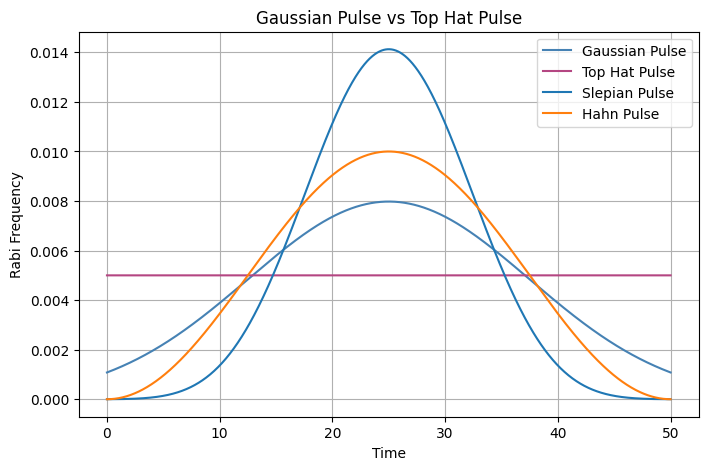

0.23862491601091226


/var/folders/r1/4bsh28x136nb61xfvz5ly0dh0000gn/T/ipykernel_19913/2245045589.py:28: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(np.trapz(gauss_pulse_values, times))


In [10]:
# create times
times = np.linspace(0, evaluation_time, evaluation_points)


slepian_root_x_rabi = make_slepian_root_x_rabi()

# Generate pulse values over time using the top hat pulse function
top_hat_pulse_values = [top_hat_root_x_rabi(t, 0)['rabi_freq'] for t in times]
gauss_pulse_values = [gaussian_root_x_rabi(t, 0)['rabi_freq'] for t in times]
slepian_pulse_values = [slepian_root_x_rabi(t, 0)['rabi_freq'] for t in times]
hahn_pulse_values = [hahn_root_x_rabi(t, 0)['rabi_freq'] for t in times]

# Plot the pulses
plt.figure(figsize=(8, 5))
plt.plot(times, gauss_pulse_values, label='Gaussian Pulse', color=steel_blue)
plt.plot(times, top_hat_pulse_values, label='Top Hat Pulse', color=plum)
plt.plot(times, slepian_pulse_values, label='Slepian Pulse')
plt.plot(times, hahn_pulse_values, label='Hahn Pulse')
plt.xlabel('Time')
plt.ylabel('Rabi Frequency')
plt.title('Gaussian Pulse vs Top Hat Pulse')
plt.legend()
plt.grid()
plt.show()


# find the area of the gaussian pulse
print(np.trapz(gauss_pulse_values, times))

In [11]:
times, Us_driving_frame = qt.calculate_unitaries_pulse(1, evaluation_time, evaluation_points, hamiltonians.rabi_rwa, slepian_root_x_rabi, detuning=0)

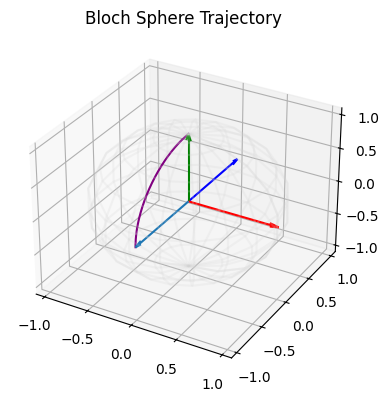

In [12]:
initial_state = np.array([1+0j,0+0j])

states = []
for U in Us_driving_frame:
    states.append(U @ initial_state)
states = np.array(states)

qt.visualise_solution(times, states)

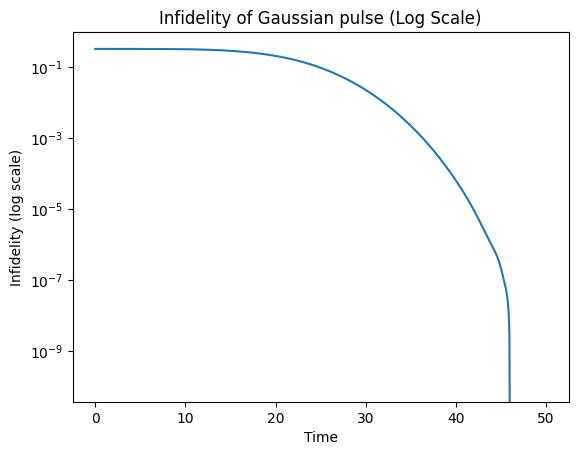

In [13]:
infids = 1 - qt.calculate_fidelities(root_x, Us_driving_frame, 2)

# Plot infidelity against time on a log scale
plt.figure()
plt.plot(times, infids)
plt.yscale("log")
plt.xlabel("Time")
plt.ylabel("Infidelity (log scale)")
plt.title("Infidelity of Gaussian pulse (Log Scale)")
plt.show()

# Now look at the cross talk

## tophat

In [14]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10
rabi_freq = 0.005





# Integration parameters
tol = 10**-12
evaluation_points = 2000
evaluation_time = 1/(4*rabi_freq)

# iteration parameters
detunings = np.linspace(0, 60*rabi_freq, 500)

fids_1 = []
fids_2 = []
fids_combined = []



# For each detuning, calculate fidelity for qubit 2 (identity gate)
for detuning in detunings:

    # calculate the effective the ccd time evolution unitaries
    times, Us_driving_frame = qt.calculate_unitaries_pulse(1, evaluation_time, evaluation_points, hamiltonians.rabi_rwa, top_hat_root_x_rabi, detuning=detuning)
    

    effective_rabi_freq = np.sign(detuning)*np.sqrt(rabi_freq**2 + detuning**2)
    transformed_Us = qt.phase_boost_unitaries(Us_driving_frame, effective_rabi_freq, times)

    # Calculate fidelity for qubit 2 (identity gate)
    fid_2 = qt.calculate_fidelities(np.eye(2), transformed_Us, 2)
    fids_2.append(fid_2)
    


# Extract the final time step fidelity for each detuning
final_fids_2_rabi_tophat = [fid[-1] for fid in fids_2]

## hahn

In [15]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10
rabi_freq = 0.005





# Integration parameters
tol = 10**-12
evaluation_points = 2000
evaluation_time = 1/(4*rabi_freq)

# iteration parameters
detunings = np.linspace(0, 60*rabi_freq, 500)

fids_1 = []
fids_2 = []
fids_combined = []



# For each detuning, calculate fidelity for qubit 2 (identity gate)
for detuning in detunings:

    # calculate the effective the ccd time evolution unitaries
    times, Us_driving_frame = qt.calculate_unitaries_pulse(1, evaluation_time, evaluation_points, hamiltonians.rabi_rwa, hahn_root_x_rabi, detuning=detuning)
    

    effective_rabi_freq = np.sign(detuning)*np.sqrt(rabi_freq**2 + detuning**2)
    transformed_Us = qt.phase_boost_unitaries(Us_driving_frame, effective_rabi_freq, times)

    # Calculate fidelity for qubit 2 (identity gate)
    fid_2 = qt.calculate_fidelities(np.eye(2), transformed_Us, 2)
    fids_2.append(fid_2)
    


# Extract the final time step fidelity for each detuning
final_fids_2_rabi_hahn = [fid[-1] for fid in fids_2]

/var/folders/r1/4bsh28x136nb61xfvz5ly0dh0000gn/T/ipykernel_19913/2355965951.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(window, t_grid)


## slepian

In [16]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10
rabi_freq = 0.005





# Integration parameters
tol = 10**-12
evaluation_points = 2000
evaluation_time = 1/(4*rabi_freq)

# iteration parameters
detunings = np.linspace(0, 60*rabi_freq, 500)

fids_1 = []
fids_2 = []
fids_combined = []

slepian_root_x_rabi = make_slepian_root_x_rabi()

# For each detuning, calculate fidelity for qubit 2 (identity gate)
for detuning in detunings:

    # calculate the effective the ccd time evolution unitaries
    times, Us_driving_frame = qt.calculate_unitaries_pulse(1, evaluation_time, evaluation_points, hamiltonians.rabi_rwa, slepian_root_x_rabi, detuning=detuning)
    

    effective_rabi_freq = np.sign(detuning)*np.sqrt(rabi_freq**2 + detuning**2)
    transformed_Us = qt.phase_boost_unitaries(Us_driving_frame, effective_rabi_freq, times)

    # Calculate fidelity for qubit 2 (identity gate)
    fid_2 = qt.calculate_fidelities(np.eye(2), transformed_Us, 2)
    fids_2.append(fid_2)
    


# Extract the final time step fidelity for each detuning
final_fids_2_rabi_slepian = [fid[-1] for fid in fids_2]

/var/folders/r1/4bsh28x136nb61xfvz5ly0dh0000gn/T/ipykernel_19913/3399462188.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_window = np.trapz(window, t_grid)


### plot the crosstalks

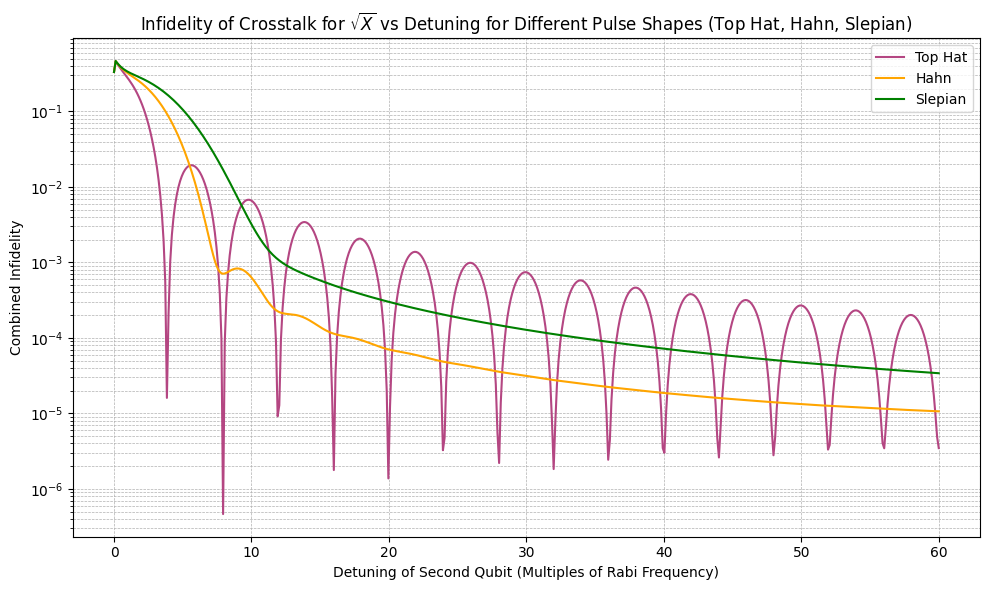

In [17]:
# find combdined infidelity
# infidelities_2_rabi_gauss = 1-np.array(final_fids_2_rabi_gauss)
infidelities_2_rabi_tophat = 1-np.array(final_fids_2_rabi_tophat)
infidelities_2_rabi_hahn = 1-np.array(final_fids_2_rabi_hahn)
infidelities_2_rabi_slepian = 1-np.array(final_fids_2_rabi_slepian)



# Plot combined infidelity vs normalized detuning on a logarithmic scale
plt.figure(figsize=(10, 6))
# plt.semilogy(detunings, infidelities_2_rabi_gauss, label="Gaussian", color=steel_blue)
plt.semilogy(detunings/0.005, infidelities_2_rabi_tophat, label="Top Hat", color=plum)
plt.semilogy(detunings/0.005, infidelities_2_rabi_hahn, label="Hahn", color="orange")
plt.semilogy(detunings/0.005, infidelities_2_rabi_slepian, label="Slepian", color="green")

# plt.semilogy(detunings, infidelities_2_ccd, label="CCD", color=plum)

plt.xlabel("Detuning of Second Qubit (Multiples of Rabi Frequency)")
plt.ylabel("Combined Infidelity")
plt.title("Combined Infidelity vs Normalized Detuning of Second Qubit for CCD Scheme and Rabi Scheme (Optimised root-X)")
plt.title(r"Infidelity of Crosstalk for $\sqrt{X}$ vs Detuning for Different Pulse Shapes (Top Hat, Hahn, Slepian)")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.savefig('/Users/archie/documents/year4/project/Figures/rabi_pulse_shaped_crosstalk.png', dpi=600)
plt.show()



# side by side panel- pulse shapes and envelopes

/var/folders/r1/4bsh28x136nb61xfvz5ly0dh0000gn/T/ipykernel_19913/2355965951.py:19: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(window, t_grid)


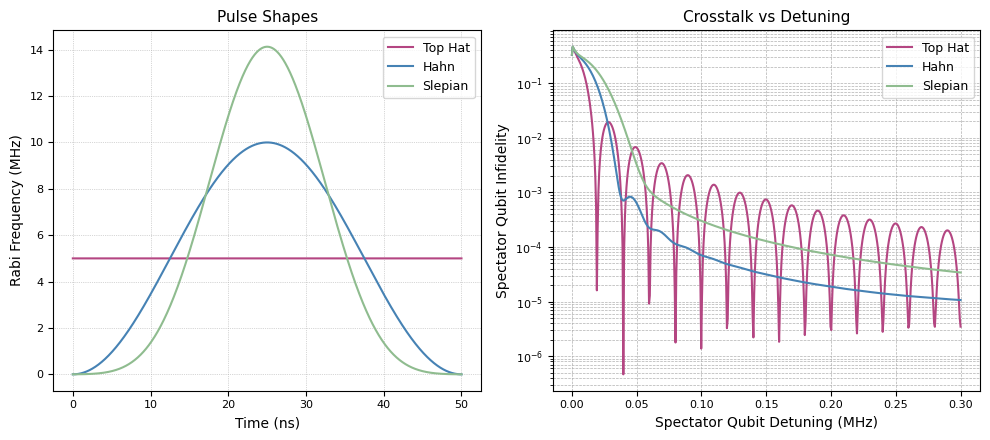

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Define colours
steel_blue, plum = "#4682B4", "#B44682"
dark_sea_green = "#8FBC8F"  # for Slepian

# Create time array
times = np.linspace(0, evaluation_time, evaluation_points)

# Generate pulse values
top_hat_pulse_values = [top_hat_root_x_rabi(t, 0)['rabi_freq'] for t in times]
hahn_pulse_values = [hahn_root_x_rabi(t, 0)['rabi_freq'] for t in times]
slepian_pulse_values = [slepian_root_x_rabi(t, 0)['rabi_freq'] for t in times]

# Convert infidelities
infidelities_tophat = 1 - np.array(final_fids_2_rabi_tophat)
infidelities_hahn = 1 - np.array(final_fids_2_rabi_hahn)
infidelities_slepian = 1 - np.array(final_fids_2_rabi_slepian)

# Normalised detunings
normalised_detunings = detunings   # Ensure it matches the shape of infidelities arrays

# Create side-by-side plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5), sharey=False)

# --- Left panel: Pulse shapes ---
ax1.plot(times, np.array(top_hat_pulse_values)*1000, label='Top Hat', color=plum)
ax1.plot(times, np.array(hahn_pulse_values)*1000, label='Hahn', color=steel_blue)
ax1.plot(times, np.array(slepian_pulse_values)*1000, label='Slepian', color=dark_sea_green)
ax1.set_xlabel('Time (ns)', fontsize=10)
ax1.set_ylabel('Rabi Frequency (MHz)', fontsize=10)
ax1.set_title('Pulse Shapes', fontsize=11)
ax1.grid(True, linestyle=':', linewidth=0.5)
ax1.legend(fontsize=9)
ax1.tick_params(axis='both', labelsize=8)

# --- Right panel: Crosstalk infidelities ---
ax2.semilogy(normalised_detunings, infidelities_tophat, label="Top Hat", color=plum)
ax2.semilogy(normalised_detunings, infidelities_hahn, label="Hahn", color=steel_blue)
ax2.semilogy(normalised_detunings, infidelities_slepian, label="Slepian", color=dark_sea_green)
ax2.set_xlabel("Spectator Qubit Detuning (MHz)", fontsize=10)
ax2.set_ylabel("Spectator Qubit Infidelity", fontsize=10)
ax2.set_title('Crosstalk vs Detuning', fontsize=11)
ax2.grid(True, which="both", linestyle="--", linewidth=0.5)
ax2.legend(fontsize=9)
ax2.tick_params(axis='both', labelsize=8)

# Final layout and export
plt.tight_layout()
plt.savefig('/Users/archie/documents/year4/project/Figures/rabi_pulse_shapes_and_crosstalk_sidebyside.png', dpi=600)
plt.show()